#Árbol KD

In [2]:
import math
import random
import matplotlib.pyplot as plt

# ─────────────────────────────
# Nodo del árbol
# ─────────────────────────────
class Nodo:
    def __init__(self, punto, eje):
        self.punto = punto
        self.eje = eje
        self.izq = None
        self.der = None


# ─────────────────────────────
# Construir KD-Tree
# ─────────────────────────────
def construir(puntos, profundidad=0):
    if not puntos:
        return None

    k = len(puntos[0])
    eje = profundidad % k  # Alternar dimensión
    puntos.sort(key=lambda p: p[eje])

    """Se supone es homogenea por generar de forma aleatoria entonces funciona así.


    """
    medio = len(puntos) // 2

    nodo = Nodo(puntos[medio], eje)
    nodo.izq = construir(puntos[:medio], profundidad + 1)
    nodo.der = construir(puntos[medio + 1:], profundidad + 1)

    return nodo


# ─────────────────────────────
# Distancia (K dimensiones)
# ─────────────────────────────
FACTOR_LAT = 111000
FACTOR_LON = 111000 * math.cos(math.radians(6.2442))

def distancia(a, b):
    dx = (a[0] - b[0]) * FACTOR_LAT
    dy = (a[1] - b[1]) * FACTOR_LON
    return math.sqrt(dx*dx + dy*dy)


# ─────────────────────────────
# Vecino más cercano
# ─────────────────────────────
def nearest(nodo, objetivo, mejor=None):
    if nodo is None:
        return mejor

    if mejor is None or distancia(objetivo, nodo.punto) < distancia(objetivo, mejor):
        mejor = nodo.punto

    eje = nodo.eje
    diff = objetivo[eje] - nodo.punto[eje]

    # lado cercano
    if diff < 0:
        mejor = nearest(nodo.izq, objetivo, mejor)
        if abs(diff) < distancia(objetivo, mejor):
            mejor = nearest(nodo.der, objetivo, mejor)
    else:
        mejor = nearest(nodo.der, objetivo, mejor)
        if abs(diff) < distancia(objetivo, mejor):
            mejor = nearest(nodo.izq, objetivo, mejor)

    return mejor


# ─────────────────────────────
# Búsqueda por radio
# ─────────────────────────────
def en_radio(nodo, centro, radio, resultado):
    if nodo is None:
        return

    if distancia(centro, nodo.punto) <= radio:
        resultado.append(nodo.punto)

    eje = nodo.eje
    if eje == 0:  # lat
        diff = (centro[0] - nodo.punto[0]) * FACTOR_LAT
    else:  # lon
        diff = (centro[1] - nodo.punto[1]) * FACTOR_LON

    # explorar lado cercano
    if diff < 0:
        en_radio(nodo.izq, centro, radio, resultado)
        if abs(diff) <= radio:
            en_radio(nodo.der, centro, radio, resultado)
    else:
        en_radio(nodo.der, centro, radio, resultado)
        if abs(diff) <= radio:
            en_radio(nodo.izq, centro, radio, resultado)



# Generación datos del árbol

In [3]:
# ─────────────────────────────
# Generador de datos
# ─────────────────────────────

def generar_puntos(seed=42, n=100):
    random.seed(seed)

    base_lat = 6.2442
    base_lon = -75.5812

    puntos = []

    for _ in range(n):
        lat = base_lat + random.uniform(-0.05, 0.05)
        lon = base_lon + random.uniform(-0.05, 0.05)
        puntos.append((lat, lon))

    return puntos

#Pruebas unitarias

**Test 1 (test_ejecucion):**
Este test básicamente revisa que todo funcione sin errores. Se crean 200 puntos aleatorios cerca de una ubicación, se arma el KD-Tree y luego se hacen dos cosas: buscar el punto más cercano a otro punto y encontrar todos los puntos dentro de 500 metros. No usa `assert`, solo sirve para ver que el programa corre bien y devuelve resultados que tienen sentido.

**Test 2 (test_punto_exacto):**
Aquí se prueba algo sencillo: si el punto que buscamos ya está en la lista, el algoritmo debería devolver ese mismo punto. Se usa un conjunto pequeño de datos y se verifica con un `assert` que el resultado sea correcto.

**Test 3 (test_estabilidad):**
Este test revisa que el resultado sea siempre el mismo. Se hace la misma búsqueda 10 veces con los mismos datos y luego se comprueba que siempre devuelve el mismo punto. Esto asegura que el algoritmo no cambia el resultado sin razón.


In [4]:

# ─────────────────────────────
# Test 1: no debe fallar con datos aleatorios
# ─────────────────────────────
def test_ejecucion():
    base_lat = 6.2442
    base_lon = -75.5812

    # puntos aleatorios en una zona pequeña (~10 km)
    puntos = [
        (
            base_lat + random.uniform(-0.05, 0.05),
            base_lon + random.uniform(-0.05, 0.05)
        )
        for _ in range(200)
    ]

    arbol = construir(puntos)

    consulta = (base_lat, base_lon)

    print("Nearest:", nearest(arbol, consulta))

    resultado = []
    en_radio(arbol, consulta, 500, resultado)  # 500 metros reales
    print("Radio:", len(resultado), "puntos encontrados")

# ─────────────────────────────
# Test 2: punto exacto debe devolverse a sí mismo
# ─────────────────────────────
def test_punto_exacto():
    puntos = [(1, 1), (2, 2), (3, 3)]
    arbol = construir(puntos)

    consulta = (2, 2)
    resultado = nearest(arbol, consulta)

    assert resultado == (2, 2)
    print("Test punto exacto OK")


# ─────────────────────────────
# Test 3: nearest es consistente (estabilidad)
# ─────────────────────────────
def test_estabilidad():
    puntos = [(random.uniform(0, 10), random.uniform(0, 10)) for _ in range(100)]
    arbol = construir(puntos)

    consulta = (4.5, 6.7)

    resultados = {nearest(arbol, consulta) for _ in range(10)}

    assert len(resultados) == 1
    print("Nearest es estable")


#─────────────────────────────
# Ejecutar tests
#─────────────────────────────
test_ejecucion()
test_punto_exacto()
test_estabilidad()


Nearest: (6.244397093084336, -75.5804536345613)
Radio: 1 puntos encontrados
Test punto exacto OK
Nearest es estable


#Visualización

En este bloque se pueden hacer las pruebas específicas para poder visualizar donde quedaría el punto a consultar y los más cercanos en el radio elegido.

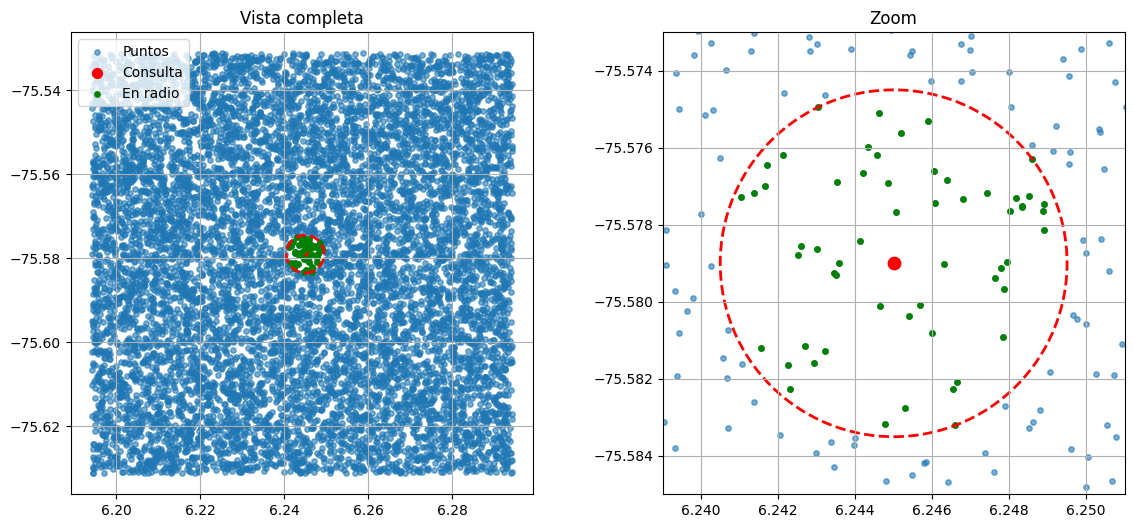

In [5]:
#─────────────────────────────
# Visualizacion
#─────────────────────────────

def visualizar_normal_y_zoom(puntos, consulta, radio_puntos=None, radio=None, zoom=0.01):
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ─────────────────────────────
    # GRÁFICO NORMAL
    # ─────────────────────────────
    axes[0].scatter(xs, ys, s=15, alpha=0.6, label="Puntos")
    axes[0].scatter(consulta[0], consulta[1], color="red", s=50, label="Consulta")

    # puntos dentro del radio
    if radio_puntos:
        xr = [p[0] for p in radio_puntos]
        yr = [p[1] for p in radio_puntos]
        axes[0].scatter(xr, yr, s=15, color="green", label="En radio")

    # círculo
    if radio:
        circle = plt.Circle(
            (consulta[0], consulta[1]),
            radio,
            color="red",
            fill=False,
            linestyle="--",
            linewidth=2
        )
        axes[0].add_patch(circle)

    axes[0].set_title("Vista completa")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_aspect("equal", adjustable="box")

    # ─────────────────────────────
    # ZOOM
    # ─────────────────────────────
    axes[1].scatter(xs, ys, s=15, alpha=0.6)
    axes[1].scatter(consulta[0], consulta[1], color="red", s=80)

    # puntos dentro del radio también en zoom
    if radio_puntos:
        xr = [p[0] for p in radio_puntos]
        yr = [p[1] for p in radio_puntos]
        axes[1].scatter(xr, yr, s=15, color="green")

    if radio:
        circle = plt.Circle(
            (consulta[0], consulta[1]),
            radio,
            color="red",
            fill=False,
            linestyle="--",
            linewidth=2
        )
        axes[1].add_patch(circle)

    axes[1].set_xlim(consulta[0] - zoom, consulta[0] + zoom)
    axes[1].set_ylim(consulta[1] - zoom, consulta[1] + zoom)

    axes[1].set_title("Zoom")
    axes[1].grid(True)
    axes[1].set_aspect("equal", adjustable="box")

    plt.show()


puntos = generar_puntos(seed=123, n=10000)

arbol = construir(puntos)


#─────────────────────────────#─────────────────────────────#─────────────────────────────
#─────────────────────────────#─────────────────────────────#─────────────────────────────
# Acá va el punto a consultar
#─────────────────────────────#─────────────────────────────#─────────────────────────────
#─────────────────────────────#─────────────────────────────#─────────────────────────────
consulta = (6.245, -75.579)

#─────────────────────────────#─────────────────────────────#─────────────────────────────
#─────────────────────────────#─────────────────────────────#─────────────────────────────
# Acá va el radio alrededor de la consulta
#─────────────────────────────#─────────────────────────────#─────────────────────────────
#─────────────────────────────#─────────────────────────────#─────────────────────────────
radio = 500
resultado = []
en_radio(arbol, consulta, radio, resultado)

visualizar_normal_y_zoom(
    puntos,
    consulta,
    radio_puntos=resultado,
    radio=radio/111000,
    zoom=0.006
)

#Fuerza bruta

In [6]:
#─────────────────────────────
# Cercano fuerza bruta
#─────────────────────────────
def nearest_bruteforce(puntos, objetivo):
    mejor = None
    mejor_dist = float("inf")

    for p in puntos:
        d = distancia(objetivo, p)
        if d < mejor_dist:
            mejor_dist = d
            mejor = p

    return mejor

#─────────────────────────────
# Radio fuerza bruta
#─────────────────────────────
def en_radio_bruteforce(puntos, centro, radio):
    return [p for p in puntos if distancia(p, centro) <= radio]

#Medición de tiempos

In [7]:
import time

#─────────────────────────────
# Comparación Nearest
#─────────────────────────────
def medir_nearest(puntos, consulta):
    import time

    # KD-Tree
    t0 = time.perf_counter()
    arbol = construir(puntos)
    t1 = time.perf_counter()

    t2 = time.perf_counter()
    r_kd = nearest(arbol, consulta)
    t3 = time.perf_counter()

    # Fuerza bruta
    t4 = time.perf_counter()
    r_brute = nearest_bruteforce(puntos, consulta)
    t5 = time.perf_counter()

    return {
        "build_kd": t1 - t0,
        "kd_time": t3 - t2,
        "brute_time": t5 - t4,
    }

#─────────────────────────────
# Comparación Radio
#─────────────────────────────
def medir_radio(puntos, consulta, radio):
    import time

    arbol = construir(puntos)

    # KD-Tree
    resultado_kd = []
    t1 = time.perf_counter()
    en_radio(arbol, consulta, radio, resultado_kd)
    t2 = time.perf_counter()

    # Fuerza bruta
    t3 = time.perf_counter()
    resultado_brute = en_radio_bruteforce(puntos, consulta, radio)
    t4 = time.perf_counter()

    return {
        "kd_time": t2 - t1,
        "brute_time": t4 - t3,
    }

#Prueba Comparación

In [14]:
#─────────────────────────────
# Prueba cercano
#─────────────────────────────

tamaños = [100, 500, 1000, 5000, 10000]

resultados_nearest = []

for n in tamaños:
    puntos = generar_puntos(n=n)
    consulta = puntos[0]

    # Construcción KD-Tree
    t0 = time.perf_counter()
    arbol = construir(puntos)
    t1 = time.perf_counter()

    # KD-Tree
    t2 = time.perf_counter()
    r_kd = nearest(arbol, consulta)
    t3 = time.perf_counter()

    # Fuerza bruta
    t4 = time.perf_counter()
    r_brute = nearest_bruteforce(puntos, consulta)
    t5 = time.perf_counter()

    resultados_nearest.append({
        "n": n,
        "build_kd": t1 - t0,
        "kd_time": t3 - t2,
        "brute_time": t5 - t4,
        "correcto": r_kd == r_brute
    })

#─────────────────────────────
# Prueba radio (n fijo)
#─────────────────────────────

import time

n = 10000  # tamaño fijo
radios = [1000, 5000, 7000, 15000, 30000]

resultados_radio = []

# Generar datos UNA vez
puntos = generar_puntos(n=n)
consulta = puntos[0]

# Construir árbol UNA vez
arbol = construir(puntos)

for r in radios:
    # KD-Tree
    resultado_kd = []
    t1 = time.perf_counter()
    en_radio(arbol, consulta, r, resultado_kd)
    t2 = time.perf_counter()

    # Fuerza bruta
    t3 = time.perf_counter()
    resultado_brute = en_radio_bruteforce(puntos, consulta, r)
    t4 = time.perf_counter()

    resultados_radio.append({
        "radio": r,
        "kd_time": t2 - t1,
        "brute_time": t4 - t3,
        "cantidad": len(resultado_kd)
    })

#─────────────────────────────
# Resultados
#─────────────────────────────

print("\nRESULTADOS VECINO CERCANO")
print("n\tBuildKD\t\tKD\t\tBrute")
print("-"*70)

for r in resultados_nearest:
    print(f"{r['n']}\t{r['build_kd']:.6f}\t{r['kd_time']:.6f}\t{r['brute_time']:.6f}")

print("\nRESULTADOS RADIO")
print("Radio\tKD\t\tBrute\t\tPuntos")
print("-"*80)

for r in resultados_radio:
    print(f"{r['radio']}\t{r['kd_time']:.6f}\t{r['brute_time']:.6f}\t{r['cantidad']}")


RESULTADOS VECINO CERCANO
n	BuildKD		KD		Brute
----------------------------------------------------------------------
100	0.003084	0.000039	0.000118
500	0.001146	0.000019	0.000123
1000	0.003249	0.000021	0.000260
5000	0.139793	0.000039	0.001947
10000	0.042497	0.000062	0.006339

RESULTADOS RADIO
Radio	KD		Brute		Puntos
--------------------------------------------------------------------------------
1000	0.000353	0.010418	152
5000	0.005415	0.006883	3240
7000	0.011221	0.006888	5502
15000	0.011642	0.006326	10000
30000	0.010935	0.005033	10000


#Grafica

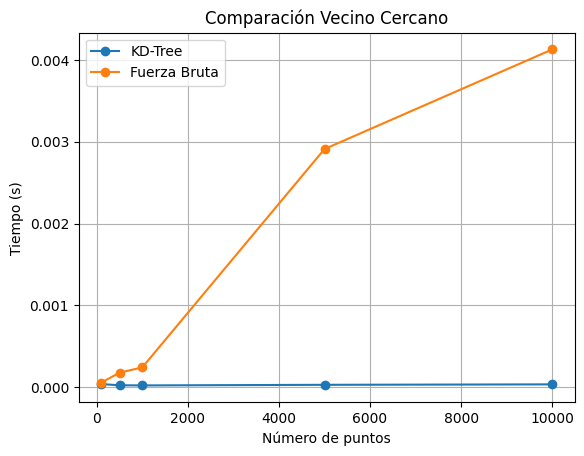

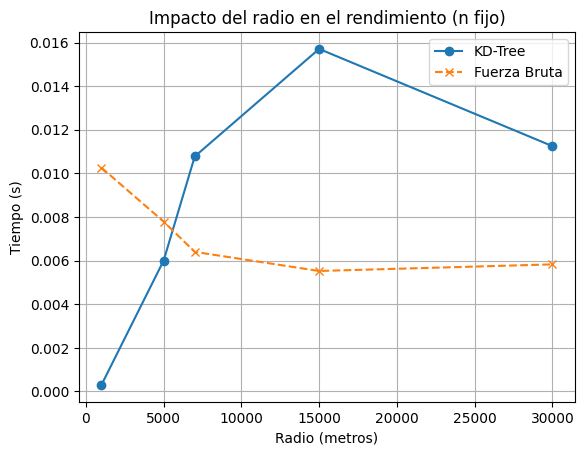

In [13]:
import matplotlib.pyplot as plt

def graficar_nearest(resultados):
    xs = [r["n"] for r in resultados]
    kd = [r["kd_time"] for r in resultados]
    brute = [r["brute_time"] for r in resultados]

    plt.figure()
    plt.plot(xs, kd, marker='o', label="KD-Tree")
    plt.plot(xs, brute, marker='o', label="Fuerza Bruta")

    plt.xlabel("Número de puntos")
    plt.ylabel("Tiempo (s)")
    plt.title("Comparación Vecino Cercano")
    plt.legend()
    plt.grid(True)
    plt.show()

graficar_nearest(resultados_nearest)

def graficar_radio_n_fijo(resultados):
    import matplotlib.pyplot as plt

    radios = []
    kd = []
    brute = []

    for r in resultados:
        radios.append(r["radio"])
        kd.append(r["kd_time"])
        brute.append(r["brute_time"])

    # Ordenar por radio
    radios, kd, brute = zip(*sorted(zip(radios, kd, brute)))

    plt.figure()

    plt.plot(radios, kd, marker='o', label="KD-Tree")
    plt.plot(radios, brute, linestyle='--', marker='x', label="Fuerza Bruta")

    plt.xlabel("Radio (metros)")
    plt.ylabel("Tiempo (s)")
    plt.title("Impacto del radio en el rendimiento (n fijo)")
    plt.legend()
    plt.grid(True)

    plt.show()

graficar_radio_n_fijo(resultados_radio)

#Análisis

##Análisis Vecino Cercano

El tiempo de construcción del KD-Tree aumenta con el número de puntos, pero el tiempo de búsqueda se mantiene prácticamente constante. En contraste, la fuerza bruta incrementa su tiempo de búsqueda conforme crecen los datos. Esto muestra que el KD-Tree escala mejor para consultas repetidas, compensando su costo inicial.

**Nota:** Esto teniendo en cuenta que sea con datos estáticos o sea un árbol que se crea una vez y no se modifica ni se tiene que crear de nuevo.



##Análisis Radio

El rendimiento del KD-Tree depende del tamaño del radio. Con radios pequeños es muy eficiente porque evalúa pocos puntos. A medida que el radio crece, debe explorar más nodos y su ventaja disminuye. Cuando el radio incluye casi todos los puntos, su comportamiento se vuelve similar o peor que fuerza bruta.

##Conclusión

El KD-Tree es eficiente para búsquedas locales y consultas de vecino más cercano, pero pierde ventaja cuando la búsqueda abarca gran parte del espacio.